# Data Wrangling — Synthetic Vietnamese Students’ Feedback

Nguồn: [Kaggle — toreleon/synthetic-vietnamese-students-feedback-corpus](https://www.kaggle.com/datasets/toreleon/synthetic-vietnamese-students-feedback-corpus)

1. `student_feedback_data/synthetic_train.csv` (train)  
2. `student_feedback_data/synthetic_val.csv` (validation)  

Dữ liệu **văn bản**: missing → làm sạch câu; chuẩn hoá đơn vị → điểm sentiment; normalize → độ dài câu; binning → ngắn/trung/dài; dummy → `topic`.

Mỗi bước có **1 dòng mẫu**. Dòng `# TODO` em làm tương tự (đổi tên cột / file).

## Download data and explore

Luôn bắt đầu bằng **nhìn dữ liệu**, đừng nhảy vào `fillna`. Hỏi: bao nhiêu dòng? cột nào object? câu rỗng / chỉ khoảng trắng?

| Cột | Kiểu | Ý nghĩa |
|---|---|---|
| `sentence` | object | Câu phản hồi (VN hoặc EN). Không trùng trong từng file. |
| `sentiment` | object | Nhãn cảm xúc: `negative` / `neutral` / `positive` (gần cân bằng). |
| `topic` | object | Chủ đề: `lecturer`, `curriculum`, `facility`, `others`. |

**Ghi chú:** Không có `NaN` sẵn. Một số câu là tiếng Anh (không dấu). Cần tạo biến số (độ dài câu) để normalize / binning.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Copy trực tiếp đường dẫn từ kết quả của kagglehub (nhớ có chữ r phía trước)
path = r"C:\Users\Legion\.cache\kagglehub\datasets\toreleon\synthetic-vietnamese-students-feedback-corpus\versions\1"

path_train = "student_feedback_data/synthetic_train.csv"
path_val = "student_feedback_data/synthetic_val.csv"

df_train = pd.read_csv(path_train)  # mẫu: đọc train
# TODO: đọc path_val vào df_val (giống dòng trên)
df_val = None

print("Train:", df_train.shape)  # mẫu: in số dòng, số cột
# TODO: in shape của df_val

print(df_train.dtypes)  # mẫu: xem kiểu cột
df_train.head()  # mẫu: 5 dòng đầu
# TODO: xem 5 dòng đầu df_val

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Copy trực tiếp đường dẫn từ kết quả của kagglehub 
path = r"C:\Users\Legion\.cache\kagglehub\datasets\toreleon\synthetic-vietnamese-students-feedback-corpus\versions\1"

# Cập nhật lại đường dẫn để nối biến path với tên file csv
path_train = f"{path}/synthetic_train.csv"
path_val = f"{path}/synthetic_val.csv"

df_train = pd.read_csv(path_train)  # mẫu: đọc train
# TODO: đọc path_val vào df_val (giống dòng trên)
df_val = pd.read_csv(path_val)

print("Train:", df_train.shape)  # mẫu: in số dòng, số cột
# TODO: in shape của df_val
print("Val:", df_val.shape)

print(df_train.dtypes)  # mẫu: xem kiểu cột
df_train.head()  # mẫu: 5 dòng đầu

# TODO: xem 5 dòng đầu df_val
df_val.head()

Train: (8144, 3)
Val: (2036, 3)
sentence     object
sentiment    object
topic        object
dtype: object


,sentence,sentiment,topic
0,Chất lượng vật chất kém.,negative,facility
1,"Phần mềm học tập quá khó sử dụng, khiến sinh v...",negative,facility
2,Trường tôi thiếu những tiện ích cơ bản như máy...,negative,facility
3,Cần tạo thêm các hoạt động gắn kết giữa sinh v...,neutral,curriculum
4,Họ rất khoan dung và lượng giác trong quan điể...,neutral,others


In [15]:

import kagglehub


# Download latest version
path = kagglehub.dataset_download("toreleon/synthetic-vietnamese-students-feedback-corpus")

print("Path to dataset files:", path)

100%|██████████| 258k/258k [00:00<00:00, 356kB/s]

Extracting files...
Path to dataset files: C:\Users\Legion\.cache\kagglehub\datasets\toreleon\synthetic-vietnamese-students-feedback-corpus\versions\1


In [1]:
!pip install kagglehub

'pip' is not recognized as an internal or external command,
operable program or batch file.


---
# Bộ 1 — Train

## 1. Xử lý giá trị thiếu (Missing Values)

Câu rỗng / chỉ khoảng trắng → `NaN`. `sentiment` / `topic` (phân loại) → **mode**. `sentence` là nội dung chính → **drop** dòng thiếu rồi `reset_index`.

In [ ]:
df = df_train.copy()  # mẫu: làm việc trên bản sao

df["sentence"] = df["sentence"].astype(str).str.strip()  # mẫu: cắt khoảng trắng câu
# TODO: strip tương tự cho sentiment và topic
# TODO: replace {"nan": np.nan, "": np.nan, "None": np.nan} trên 3 cột (có thể dùng vòng for)

print(df.isnull().sum())  # mẫu: đếm missing trước xử lý

df["sentiment"] = df["sentiment"].fillna(df["sentiment"].mode(dropna=True)[0])  # mẫu: cột chữ → mode
# TODO: fillna mode cho cột topic (copy mẫu, đổi tên cột)

# TODO: dropna subset=["sentence"] rồi reset_index (câu là nội dung chính — không điền mode)

# TODO: in lại isnull().sum() và len(df)

In [3]:
df = df_train.copy() # mẫu: làm việc trên bản sao

# Cắt khoảng trắng cho cả 3 cột
df["sentence"] = df["sentence"].astype(str).str.strip() # mẫu: cắt khoảng trắng câu
df["sentiment"] = df["sentiment"].astype(str).str.strip()
df["topic"] = df["topic"].astype(str).str.strip()

# Thay thế các giá trị rỗng ảo thành NaN chuẩn của Numpy
cols = ["sentence", "sentiment", "topic"]
for col in cols:
    df[col] = df[col].replace({"nan": np.nan, "": np.nan, "None": np.nan})

print("--- Missing trước xử lý ---")
print(df.isnull().sum()) # mẫu: đếm missing trước xử lý

# Điền giá trị thiếu (fillna) bằng mode (giá trị xuất hiện nhiều nhất)
df["sentiment"] = df["sentiment"].fillna(df["sentiment"].mode(dropna=True)[0]) # mẫu: cột chữ -> mode
df["topic"] = df["topic"].fillna(df["topic"].mode(dropna=True)[0])

# Xóa các dòng thiếu câu review (nội dung chính) và reset lại index
df = df.dropna(subset=["sentence"]).reset_index(drop=True)

# Kiểm tra lại kết quả
print("\n--- Missing sau xử lý ---")
print(df.isnull().sum())
print("Tổng số dòng còn lại (len):", len(df))

--- Missing trước xử lý ---
sentence     0
sentiment    0
topic        0
dtype: int64

--- Missing sau xử lý ---
sentence     0
sentiment    0
topic        0
dtype: int64
Tổng số dòng còn lại (len): 8144


## 2. Sửa định dạng dữ liệu (Correct Data Format)

Ép `sentiment`, `topic` về kiểu `category`. Thêm độ dài câu (`n_chars`, `n_words`) dạng số.

In [ ]:
print(df.dtypes)  # mẫu: kiểu trước khi ép

df["sentiment"] = df["sentiment"].astype("category")  # mẫu: chữ → category
# TODO: ép topic về category (giống dòng trên)

df["n_chars"] = df["sentence"].str.len().astype(int)  # mẫu: số ký tự
# TODO: n_words = sentence.str.split().str.len() rồi astype(int)

df[["sentence", "n_chars"]].head()  # mẫu
# TODO: head thêm cột n_words; in lại dtypes

In [4]:
print("Kiểu dữ liệu trước khi ép:")
print(df.dtypes) 

df["sentiment"] = df["sentiment"].astype("category") # mẫu: chữ -> category
# TODO: ép topic về category (giống dòng trên)
df["topic"] = df["topic"].astype("category")

df["n_chars"] = df["sentence"].str.len().astype(int) # mẫu: số ký tự
# TODO: n_words = sentence.str.split().str.len() rồi astype(int)
df["n_words"] = df["sentence"].str.split().str.len().astype(int)

# In lại dtypes để kiểm tra xem sentiment và topic đã chuyển thành category chưa
print("\nKiểu dữ liệu sau khi ép:")
print(df.dtypes)

# TODO: head thêm cột n_words
df[["sentence", "n_chars", "n_words"]].head()

Kiểu dữ liệu trước khi ép:
sentence     object
sentiment    object
topic        object
dtype: object

Kiểu dữ liệu sau khi ép:
sentence       object
sentiment    category
topic        category
n_chars         int64
n_words         int64
dtype: object


,sentence,n_chars,n_words
0,Đội ngũ bảo trì quá thưa thớt dẫn đến không đả...,86,19
1,The university's musical and artistic faciliti...,63,8
2,Phương pháp giảng dạy phù hợp với các đối tượn...,68,14
3,Chương trình học giúp tôi trở thành một chuyên...,75,15
4,Tôi nghĩ rằng chương trình đào tạo có thể có t...,142,34


## 3. Chuẩn hoá dữ liệu (Data Standardization)

Đưa nhãn cảm xúc về **cùng thang số**: `negative → -1`, `neutral → 0`, `positive → 1`.

In [ ]:
sentiment_map = {"negative": -1, "neutral": 0, "positive": 1}  # mẫu: từ điển nhãn → số

# TODO: cột sentiment_score = df["sentiment"].map(sentiment_map).astype(int)

df[["sentiment"]].drop_duplicates()  # mẫu: xem các nhãn
# TODO: head / drop_duplicates hai cột sentiment và sentiment_score

In [5]:
sentiment_map = {"negative": -1, "neutral": 0, "positive": 1} # mẫu: từ điển nhãn -> số

# Tạo cột điểm số mới dựa trên từ điển mapping
df["sentiment_score"] = df["sentiment"].map(sentiment_map).astype(int)

# Xem các nhãn duy nhất để kiểm tra xem việc map số (-1, 0, 1) đã khớp chính xác với chữ chưa
df[["sentiment", "sentiment_score"]].drop_duplicates()

,sentiment,sentiment_score
0,negative,-1
1,neutral,0
3,positive,1


## 4. Chuẩn hoá phạm vi giá trị (Data Normalization)

`n_chars` lớn hơn `n_words` → `x / x.max()` về 0–1.

In [ ]:
df["n_chars_normalized"] = df["n_chars"] / df["n_chars"].max()  # mẫu: chia max → 0–1
# TODO: n_words_normalized = n_words / n_words.max()

df[["n_chars", "n_chars_normalized"]].head()  # mẫu
# TODO: head thêm n_words và n_words_normalized

In [6]:
df["n_chars_normalized"] = df["n_chars"] / df["n_chars"].max() 
df["n_words_normalized"] = df["n_words"] / df["n_words"].max()

# Hiển thị gộp cả 4 cột để dễ dàng đối chiếu kết quả trước và sau khi chuẩn hoá
df[["n_chars", "n_chars_normalized", "n_words", "n_words_normalized"]].head()

,n_chars,n_chars_normalized,n_words,n_words_normalized
0,86,0.452632,19,0.441860
1,63,0.331579,8,0.186047
2,68,0.357895,14,0.325581
3,75,0.394737,15,0.348837
4,142,0.747368,34,0.790698


## 5. Phân nhóm (Binning)

Chia độ dài câu (số từ) thành Short / Medium / Long bằng `pd.cut()`.

In [ ]:
bins = np.linspace(df["n_words"].min(), df["n_words"].max(), 4)  # mẫu: 3 khoảng đều

df["length_binned"] = pd.cut(
    df["n_words"], bins=bins, labels=["Short", "Medium", "Long"], include_lowest=True
)  # mẫu: gán nhãn

print(df["length_binned"].value_counts())  # mẫu: đếm mỗi nhóm

# TODO: plt.hist(df["n_words"], bins=3) rồi xlabel / ylabel / title / show

df[["n_words", "length_binned"]].head()

Số lượng câu trong mỗi nhóm:
length_binned
Short     5070
Medium    2978
Long        96
Name: count, dtype: int64


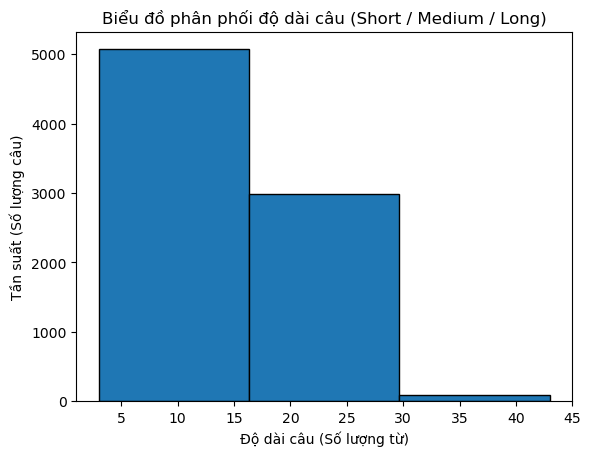

,n_words,length_binned
0,19,Medium
1,8,Short
2,14,Short
3,15,Short
4,34,Long


In [10]:
# 1. Tạo các khoảng (bins) và phân nhóm dữ liệu
bins = np.linspace(df["n_words"].min(), df["n_words"].max(), 4) # 3 khoảng đều nhau

df["length_binned"] = pd.cut(
    df["n_words"], bins=bins, labels=["Short", "Medium", "Long"], include_lowest=True
)

print("Số lượng câu trong mỗi nhóm:")
print(df["length_binned"].value_counts())

# 2. Trực quan hoá phân phối độ dài câu bằng Histogram
plt.hist(df["n_words"], bins=3, edgecolor='black')
plt.xlabel("Độ dài câu (Số lượng từ)")
plt.ylabel("Tần suất (Số lượng câu)")
plt.title("Biểu đồ phân phối độ dài câu (Short / Medium / Long)")
plt.show()

# 3. Hiển thị kết quả dataframe
df[["n_words", "length_binned"]].head()

## 6. Biến chỉ thị / Biến giả (Dummy Variable)

`topic` (chữ) → mỗi chủ đề một cột 0/1. Giữ `sentiment` làm nhãn dự đoán.

In [ ]:
dummy_topic = pd.get_dummies(df["topic"], prefix="topic", dtype=int)  # mẫu: cột 0/1

# TODO: gộp dummy vào df — pd.concat([df, dummy_topic], axis=1)

# TODO: xoá cột gốc topic — df.drop(columns=["topic"])  (giữ sentiment)

df.head()  # mẫu

In [11]:
dummy_topic = pd.get_dummies(df["topic"], prefix="topic", dtype=int) # mẫu: cột 0/1

# Gộp các cột dummy vừa tạo vào DataFrame gốc (thêm theo chiều ngang: axis=1)
df = pd.concat([df, dummy_topic], axis=1)

# Xoá cột 'topic' gốc chữ vì đã có các cột số thay thế
df = df.drop(columns=["topic"])

# Hiển thị kết quả để kiểm tra các cột mới
df.head()

,sentence,sentiment,n_chars,n_words,sentiment_score,n_chars_normalized,n_words_normalized,length_binned,topic_curriculum,topic_facility,topic_lecturer,topic_others
0,Đội ngũ bảo trì quá thưa thớt dẫn đến không đả...,negative,86,19,-1,0.452632,0.441860,Medium,0,1,0,0
1,The university's musical and artistic faciliti...,neutral,63,8,0,0.331579,0.186047,Short,0,1,0,0
2,Phương pháp giảng dạy phù hợp với các đối tượn...,neutral,68,14,0,0.357895,0.325581,Short,1,0,0,0
3,Chương trình học giúp tôi trở thành một chuyên...,positive,75,15,1,0.394737,0.348837,Short,1,0,0,0
4,Tôi nghĩ rằng chương trình đào tạo có thể có t...,neutral,142,34,0,0.747368,0.790698,Long,1,0,0,0


## Check and save

Trước khi `to_csv`:

* `isnull().sum()` còn 0 (hoặc đúng chỗ cố ý để thiếu)
* `n_chars`, `n_words` là số
* có cột mới: `sentiment_score`, `*_normalized`, `length_binned`, `topic_*`

`index=False` để file không thêm cột index 0,1,2,…


In [ ]:
df.to_csv("student_feedback_train_clean.csv", index=False)  # mẫu: lưu train
print(df.shape)

# TODO: (tuỳ chọn) gán df_train_clean = df

In [12]:
# Lưu dataframe ra file CSV, bỏ qua cột số thứ tự index
df.to_csv("student_feedback_train_clean.csv", index=False) 
print("Kích thước dữ liệu tập Train sau khi làm sạch:", df.shape)

# Gán biến mới để lưu trữ bản sạch (sử dụng .copy() để tách biệt hoàn toàn với df hiện tại)
df_train_clean = df.copy()

Kích thước dữ liệu tập Train sau khi làm sạch: (8144, 12)


---
---
# Bộ 2 — Validation

Làm **giống bộ train**, đổi `df_train` → `df_val`. Copy mẫu ở trên, sửa tên biến / title. Kết thúc bằng **Check and save** (`to_csv`, `index=False`).


In [ ]:
df = df_val.copy()  # mẫu: bắt đầu từ validation

df["sentence"] = df["sentence"].astype(str).str.strip()  # mẫu bước 1
# TODO: strip + replace nan/""/"None" cho sentiment, topic; fillna mode; dropna sentence

df["sentiment"] = df["sentiment"].astype("category")  # mẫu bước 2
# TODO: ép topic; tạo n_chars (đã có mẫu train) và n_words

sentiment_map = {"negative": -1, "neutral": 0, "positive": 1}  # mẫu bước 3
# TODO: sentiment_score = map rồi astype(int)

df["n_chars_normalized"] = df["n_chars"] / df["n_chars"].max()  # mẫu bước 4
# TODO: n_words_normalized

# TODO: bước 5 — linspace + pd.cut + value_counts + hist (title Val)

dummy_topic = pd.get_dummies(df["topic"], prefix="topic", dtype=int)  # mẫu bước 6
# TODO: concat + drop topic

# TODO: to_csv student_feedback_val_clean.csv; print shape; df.head()

Số lượng câu mỗi nhóm (Validation):
length_binned
Short     1385
Medium     634
Long        17
Name: count, dtype: int64


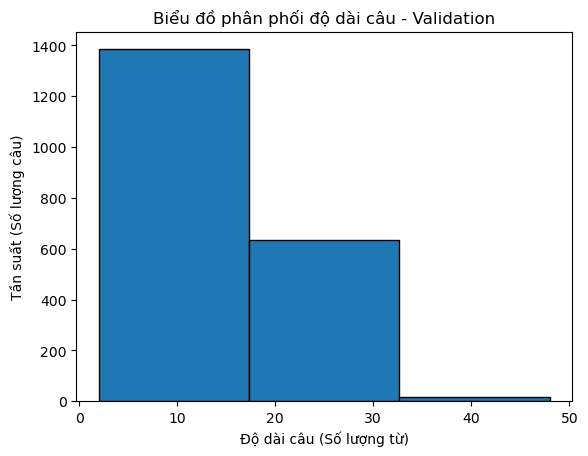


Kích thước tập Validation sau khi làm sạch: (2036, 12)


,sentence,sentiment,n_chars,n_words,sentiment_score,n_chars_normalized,n_words_normalized,length_binned,topic_curriculum,topic_facility,topic_lecturer,topic_others
0,Chất lượng vật chất kém.,negative,24,5,-1,0.112150,0.104167,Short,0,1,0,0
1,"Phần mềm học tập quá khó sử dụng, khiến sinh v...",negative,68,15,-1,0.317757,0.312500,Short,0,1,0,0
2,Trường tôi thiếu những tiện ích cơ bản như máy...,negative,120,25,-1,0.560748,0.520833,Medium,0,1,0,0
3,Cần tạo thêm các hoạt động gắn kết giữa sinh v...,neutral,64,14,0,0.299065,0.291667,Short,1,0,0,0
4,Họ rất khoan dung và lượng giác trong quan điể...,neutral,57,12,0,0.266355,0.250000,Short,0,0,0,1


In [13]:
df = df_val.copy() # mẫu: bắt đầu từ validation

# --- BƯỚC 1: Xử lý giá trị thiếu ---
df["sentence"] = df["sentence"].astype(str).str.strip() # mẫu bước 1
df["sentiment"] = df["sentiment"].astype(str).str.strip()
df["topic"] = df["topic"].astype(str).str.strip()

cols = ["sentence", "sentiment", "topic"]
for col in cols:
    df[col] = df[col].replace({"nan": np.nan, "": np.nan, "None": np.nan})

df["sentiment"] = df["sentiment"].fillna(df["sentiment"].mode(dropna=True)[0])
df["topic"] = df["topic"].fillna(df["topic"].mode(dropna=True)[0])
df = df.dropna(subset=["sentence"]).reset_index(drop=True)

# --- BƯỚC 2: Sửa định dạng dữ liệu ---
df["sentiment"] = df["sentiment"].astype("category") # mẫu bước 2
df["topic"] = df["topic"].astype("category")
df["n_chars"] = df["sentence"].str.len().astype(int)
df["n_words"] = df["sentence"].str.split().str.len().astype(int)

# --- BƯỚC 3: Chuẩn hoá dữ liệu (Sentiment) ---
sentiment_map = {"negative": -1, "neutral": 0, "positive": 1} # mẫu bước 3
df["sentiment_score"] = df["sentiment"].map(sentiment_map).astype(int)

# --- BƯỚC 4: Chuẩn hoá phạm vi (Normalize) ---
df["n_chars_normalized"] = df["n_chars"] / df["n_chars"].max() # mẫu bước 4
df["n_words_normalized"] = df["n_words"] / df["n_words"].max()

# --- BƯỚC 5: Phân nhóm (Binning) ---
bins = np.linspace(df["n_words"].min(), df["n_words"].max(), 4)
df["length_binned"] = pd.cut(df["n_words"], bins=bins, labels=["Short", "Medium", "Long"], include_lowest=True)

print("Số lượng câu mỗi nhóm (Validation):")
print(df["length_binned"].value_counts())

plt.hist(df["n_words"], bins=3, edgecolor='black')
plt.xlabel("Độ dài câu (Số lượng từ)")
plt.ylabel("Tần suất (Số lượng câu)")
plt.title("Biểu đồ phân phối độ dài câu - Validation")
plt.show()

# --- BƯỚC 6: Biến giả (Dummy Variable) ---
dummy_topic = pd.get_dummies(df["topic"], prefix="topic", dtype=int) # mẫu bước 6
df = pd.concat([df, dummy_topic], axis=1)
df = df.drop(columns=["topic"])

# --- Check and save ---
df.to_csv("student_feedback_val_clean.csv", index=False)
print("\nKích thước tập Validation sau khi làm sạch:", df.shape)

# Gán lại biến cho tập val và in 5 dòng đầu
df_val_clean = df.copy()
df_val_clean.head()